# US equities panel: capacity, loss function, and when to stop adding trees

[`06_linear`](06_linear.ipynb) fitted a penalty grid to these features and found what a linear
map of them is worth. A linear model can only represent a relationship it is handed in the right
shape: it sees an interaction between momentum and volatility only because someone multiplied
those columns together and named the product. Gradient boosting has no such restriction. It
builds a sequence of shallow trees, each fitted to what the ones before it got wrong, and a tree
splits on one feature inside a region defined by others - so an interaction is something it can
find rather than something it must be given.

That freedom is the whole question. A model that can represent anything can also fit noise, and
with roughly three thousand names and ten years of training window behind each fold there is
plenty of both to work with. Three dials control how far it goes, and this notebook varies all
three:

- **Capacity**, set by `num_leaves`: how many regions one tree may carve the feature space into.
  Seven leaves express a handful of conditions; 63 can express a partition fine enough to
  describe the training window and nothing beyond it.
- **The loss function**, which decides what "got wrong" means. `mse` minimizes squared error,
  `mae` absolute error, and `huber` behaves like squared error for small residuals and like
  absolute error past a threshold derived from each fold's own label spread. Cross-sectional
  equity returns are heavy-tailed, and squared error weights an observation by the square of its
  error, so a handful of extreme moves can carry hundreds of times the weight of a typical one.
  The comparison between the three objectives is a comparison of how far the tails are allowed
  to steer the fit - and rank IC, the metric below, is indifferent to exactly the magnitudes
  squared error chases.
- **When to stop**, set by the number of trees. Unlike a linear fit, a boosted model has a
  meaningful state at every iteration, so each configuration is scored at ten points along its
  own training run rather than only at the end.

The third dial changes how the results must be read. **A checkpoint is part of a configuration,
not a detail of how it was fitted.** Scoring the declared grid at ten checkpoints each
multiplies the candidate count by ten, and treating that as one candidate per configuration
while quietly keeping each one's best iteration would be reporting the maximum of ten numbers as
though it were one.

**Learning objectives.** By the end of this notebook you will be able to:

- Read a declared gradient boosting grid and say what each configuration varies.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and tell
  apart a model still learning from one that has begun fitting the training window.
- Say why the choice of loss function is a statement about the label's tails, and relate that to
  what a rank-based metric rewards.
- Compare the same grid across three prediction horizons and say what a reversal between them
  rules out.
- Recognise that picking each configuration's best checkpoint after seeing the results is a
  selection decision, and locate where selection is actually made.

**Docker image**: `ml4t`

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) fitted the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration, label and checkpoint, in `run_log/registry.db` and under
`run_log/training/` and `run_log/predictions/`, grouped under a named population.
[`16_backtest`](16_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared US equities panel gradient boosting population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from plotly.subplots import make_subplots

from case_studies.research import (
    candidate_set_supersedes,
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    plan_models,
    planned_model_plan,
    primary_label,
    run_model_population,
    supersedes_for_run,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
DIAGNOSTIC_CONFIG_NAMES = ["default_mse"]
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = "1ce92c9f8dc0"

# A candidate set is sealed once written, so a run whose members differ from the recorded
# generation has to name the set it replaces, keyed by the full set name because that is what
# the refusal prints. Both moved when 04_model_based_features was rebuilt at production scale
# on 2026-09-10: all 15 registered gbm runs pin `model_based` at sha256 86ece972 and the file on
# disk is 0e74d15f, so every one is unreachable and the catalog refits from cold. `fwd_ret_5d`
# and `fwd_ret_21d` have no recorded generation and need no entry - `create` refuses a first
# version that claims to replace one. Resolved through `candidate_set_supersedes` rather than
# passed straight to `freeze`, so a reader's clean clone publishes generation one.
SUPERSEDES_SETS: dict = {
    "us-equities-fwd-ret-1d-gbm-v1": "464646b3bd65",
    "us-equities-fwd-ret-1d-gbm-diagnostics-v1": "30766ca63471",
}

In [3]:
study = open_study("us_equities_panel", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which labels, and which models

The labels are the three [`06_linear`](06_linear.ipynb) fitted: `fwd_ret_1d`, the primary one,
and `fwd_ret_5d` and `fwd_ret_21d` at longer horizons. Keeping the label set the same across the
two notebooks is what makes their populations comparable - the families differ, the targets do
not.

**`LABELS = []` fits all of them in one run**, which is what the empty list means: not "no
labels" but "every label whose training menu declares this family". Each label carries its own
menu at `config/training/{label}.yaml`.

In [4]:
declared_labels(study, "gbm")

('fwd_ret_1d', 'fwd_ret_21d', 'fwd_ret_5d')

Each name resolves to a preset in `case_studies/config/lgb/` holding the complete LightGBM
parameter set. The grid is a product of two axes:

- **A capacity ladder** at 7, 15, 31 and 63 leaves, plus a `default` profile.
- **Three objectives**, as described above.

**`default` is not a fifth rung, and the grid does not isolate capacity.** The `params` block of
each `default_*` preset holds only `objective` and `seed`; the frame above shows both blocks side
by side. `default_huber` also declares a top-level `huber_alpha_scale`, but every `leaves_*_huber`
declares the same value, so it separates the objectives from each other and not `default` from the
ladder.

Everything a `default_*` preset leaves out is filled by LightGBM's own default, and that is where
the two profiles part company. Its default leaf limit is the `leaves_31` rung, so the two agree on
the axis the ladder varies. It runs at twice the learning rate the twelve `leaves_*` presets
declare. And it carries none of their `bagging_fraction`, `bagging_freq`, `feature_fraction`,
`lambda_l1`, `lambda_l2` or `min_child_samples`, which resolve to no L1 or L2 penalty at all,
subsampling switched off rather than merely weakened, and a minimum leaf size well under half the
ladder's. So `default` and `leaves_31` share a leaf limit and not a capacity: seven declared
parameters apart rather than none.

Read the gap between them as capacity and you will be reading the wrong axis. The two sit side
by side in the final-iteration chart in Section 4 at identical leaf counts, and whatever
separates them there is those seven parameters rather than the number of regions a tree may
carve. A library default is a property of the installed version, so the resolved values the fit
actually used are the ones in the training specification the run registers, not these.

What the grid does hold fixed is training length - every configuration declares
`max_iterations: 500` and `checkpoint_interval: 50` - so the checkpoint comparison below is
sound even where the capacity comparison is not.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_ret_1d""","""default_mse""","""lightgbm.Booster""","""objective=regression, seed=42"""
"""gbm""","""fwd_ret_1d""","""default_mae""","""lightgbm.Booster""","""objective=regression_l1, seed=…"
"""gbm""","""fwd_ret_1d""","""default_huber""","""lightgbm.Booster""","""objective=huber, seed=42"""
"""gbm""","""fwd_ret_1d""","""leaves_7_mse""","""lightgbm.Booster""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_1d""","""leaves_7_mae""","""lightgbm.Booster""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_5d""","""leaves_31_mae""","""lightgbm.Booster""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_5d""","""leaves_31_huber""","""lightgbm.Booster""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_5d""","""leaves_63_mse""","""lightgbm.Booster""","""bagging_fraction=0.8, bagging_…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
population from the canonical one. Publishing it under the canonical name would leave that name
meaning two different member sets at two different times, so the guard below requires a run that
narrows anything to say what to call its population.

In [6]:
if narrows_declared_catalog(study, "gbm", configs) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the declared configurations, so it cannot publish "
        "the canonical population; pass POPULATION_NAME to give it its own"
    )

# Only an unnarrowed canonical run publishes the diagnostic set, so only that run has to carry
# every diagnostic configuration. A narrowed or preview run publishes no name and is free to
# leave any of them out.
is_published_population = (
    EXECUTION_TIER == "canonical" and not POPULATION_NAME and not PREVIEW_REDUCTIONS
)
if is_published_population:
    unknown_diagnostics = sorted(
        set(DIAGNOSTIC_CONFIG_NAMES) - set(configs.get_column("config_name").unique().to_list())
    )
    if not DIAGNOSTIC_CONFIG_NAMES or unknown_diagnostics:
        raise ValueError(
            "an unnarrowed canonical run publishes the diagnostic set, so its configurations "
            f"have to be among the ones fitted: {unknown_diagnostics}"
        )

## 2. Binding the declarations to the data

**Planning** works out every training and prediction identity from the declarations and the fold
boundaries in `config/setup.yaml`, without holding the data it derived them from. On a panel
this size that is not an optimization but the only workable order: a *resolved* request carries
its prepared folds, so resolving the whole grid before fitting would hold one copy per
configuration of a three-thousand-name panel across sixteen ten-year training windows. Execution
walks folds on the outside and configurations on the inside, so one prepared fold is live at a
time however many configurations were declared.

Four things to check in the table below:

- **`feature_count` and `eligible_rows` agree within a label.** A row that differs is a
  configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration publishes predictions for. Multiply it by the number of rows to get
  the number of candidate models this notebook is about to create.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
    notebook="07_gbm",
)
plan = plan_models(study, requests=requests)

planned = planned_model_plan(plan)
planned.select(
    "label",
    "config_name",
    "task",
    "feature_count",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,task,feature_count,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,str,i64,i64,i64,i64,str,str
"""fwd_ret_1d""","""default_huber""","""regression""",71,7170323,16,10,"""1999-12-22 00:00:00""","""2015-12-30 00:00:00"""
"""fwd_ret_1d""","""default_mae""","""regression""",71,7170323,16,10,"""1999-12-22 00:00:00""","""2015-12-30 00:00:00"""
"""fwd_ret_1d""","""default_mse""","""regression""",71,7170323,16,10,"""1999-12-22 00:00:00""","""2015-12-30 00:00:00"""
"""fwd_ret_1d""","""leaves_15_huber""","""regression""",71,7170323,16,10,"""1999-12-22 00:00:00""","""2015-12-30 00:00:00"""
"""fwd_ret_1d""","""leaves_15_mae""","""regression""",71,7170323,16,10,"""1999-12-22 00:00:00""","""2015-12-30 00:00:00"""
…,…,…,…,…,…,…,…,…
"""fwd_ret_5d""","""leaves_63_mae""","""regression""",71,7160171,16,10,"""1999-12-22 00:00:00""","""2015-12-23 00:00:00"""
"""fwd_ret_5d""","""leaves_63_mse""","""regression""",71,7160171,16,10,"""1999-12-22 00:00:00""","""2015-12-23 00:00:00"""
"""fwd_ret_5d""","""leaves_7_huber""","""regression""",71,7160171,16,10,"""1999-12-22 00:00:00""","""2015-12-23 00:00:00"""


## 3. Fitting the population

`run_model_population` fits every planned request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

**How many bins the features are quantized into is part of the model, not a property of the
machine.** LightGBM buckets each feature's values before considering any split, and the same
data at 63 bins and at 255 produces different trees. `config/setup.yaml` declares `max_bin`
explicitly for that reason. Reading it off whichever device happened to be visible - the GPU
default is 63, the CPU default 255 - would let two runs of the same named configuration fit
different models and register them under the same name.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined. Each configuration
registers as it completes rather than at the end, so an interruption costs the configuration in
flight and nothing else.

**One population covers all three labels**, because one run fits them all and the population is
what that run declares. A population is immutable once written, so a notebook that fitted one
label per run under a single name would publish the first label and be refused for the second.

`SUPERSEDES_POPULATION` names the population hash this run replaces. A changed estimator
parameter moves every training identity as surely as a changed menu does, so the refit is a
different population under the same name and the registry refuses to write it without being told
which snapshot it supersedes. That lineage is the only record of which generation is which.

A declared `SUPERSEDES_POPULATION` hash only means something where a generation of this name
already exists. A preview run, a first canonical run against an empty `run_log/`, and a run
under a caller-chosen `POPULATION_NAME` are all refused by `OfficialPopulation.create` if one
is passed anyway, so `supersedes_for_run` works out which of those cases this run is and
resolves the hash accordingly.

In [8]:
population_name = POPULATION_NAME or "us-equities-gbm-checkpoints-v1"
supersedes = supersedes_for_run(
    study,
    population_name=population_name,
    declared=SUPERSEDES_POPULATION,
    execution_tier=EXECUTION_TIER,
)
execution, population = run_model_population(
    study,
    plan,
    population_name=population_name,
    supersedes=supersedes,
)

fitted = sum(len(item["fitted_folds"]) for item in execution.diagnostics)
reused = sum(len(item["reused_folds"]) for item in execution.diagnostics)
print(f"{len(execution.runs)} configurations: {fitted} folds fitted, {reused} reused")
print(f"population {population.name}: {len(population.members)} prediction sets")

      fold 9: training n_train=3,590,036 n_val=436,518 trees=500 num_leaves=15 obj=regression


      fold 9: done in 57s


      fold 9: training n_train=3,590,036 n_val=436,518 trees=500 num_leaves=15 obj=regression_l1


      fold 9: done in 87s


      fold 9: training n_train=3,590,036 n_val=436,518 trees=500 num_leaves=15 obj=huber


...

      fold 15: training n_train=4,997,063 n_val=597,026 trees=500 num_leaves=63 obj=regression_l1


      fold 15: done in 122s


      fold 15: training n_train=4,997,063 n_val=597,026 trees=500 num_leaves=63 obj=huber


      fold 15: done in 114s


45 configurations: 99 folds fitted, 621 reused
population us-equities-gbm-checkpoints-v1: 450 prediction sets


### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("us_equities_panel", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_1d"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
plan = plan_models(study, requests=requests)
execution, population = run_model_population(study, plan, population_name="my-gbm-v1")
```

Narrow to a couple of configurations on one label before running anything wide here: at panel
scale a full grid is hours, and the point of a first pass is to find out that the plumbing works.
To fit something new, add a preset at `case_studies/config/lgb/leaves_127_huber.yaml` and list
`leaves_127_huber` under `gbm:` in the label's menu. Editing an existing preset changes that
configuration's identity, so its result registers as a new row beside the old one rather than
replacing it. [`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration, label and checkpoint. `ic_mean` is the **information coefficient**: on
each validation date, rank the names by the model's prediction, rank them by the return they went
on to earn, correlate the two rankings, and average that daily correlation over the validation
period.

The table is sorted by label and then by IC, and the top of each label's block is the trap this
notebook exists to describe. The leading row for a label is the maximum over the whole grid at
ten checkpoints each. Reading it as the result of one experiment would attribute to the model
whatever the stopping point contributed, and the section below measures how large that
contribution is before anything is concluded from the ranking.

Coverage is judged against each label's own maximum number of scorable validation dates, since a
longer forward window runs out earlier and one global maximum would mark a whole label
incomplete for a reason unrelated to any model.

### What the run produced, and the sets it publishes

The cell below reports both, because they are one statement: the population is one immutable
list covering every label this run fitted, and the candidate sets are the names the later
notebooks open it by.

`16_backtest` never opens the population: it opens *candidate sets*, named per
`(label, family)`, because a comparison is only meaningful within one label's protocol.
`15_model_analysis` opens both - the population, to confirm the run filled every member it
promised, and the candidate sets, to make the comparison. Freezing is what creates those names.

Without this the two downstream notebooks name six sets that nothing produces, and they fail
differently: `15` raises when `CandidateSet.one` cannot find the name, while `16` would simply
backtest whatever subset of names does resolve. A missing name is a silently narrower strategy
chain, which is the failure the named-set design exists to prevent.

The diagnostic subset is bounded hard, and the reason is arithmetic. `15` loads every diagnostic
member's raw prediction frame and holds them all while it joins them pairwise; one frame on this
panel is over seven million rows and about 225 MB in memory. So the set is one member per label and
family: the diagnostic configuration at its last checkpoint. `default_mse` is that configuration
here - the untuned starting point the leaf and objective sweeps vary from - and its last
checkpoint is the state a reader would compare against another family's finished fit. The
checkpoint dimension is not lost by bounding it away: the learning curves above are where it is
read, and they are drawn from registry metrics rather than from raw frames.

Only an unnarrowed canonical run publishes. The guard on `narrows_declared_catalog` above already
refuses to publish the canonical *population* from a narrowed run; the same condition governs the
canonical set names, for the same reason - a name must not mean two different member sets.

In [9]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort(["label", "ic_mean"], descending=[False, True])

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels by
# whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
order_label = panel_labels[0]
print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each, on {len(panel_labels)} labels")
# `display` rather than a bare expression: a cell renders only its last value, and this cell
# ends with the frozen-set table. Without it the model results table would be computed and
# never shown.
display(
    catalog.select(
        "label",
        "config_name",
        "checkpoint_value",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "full_coverage",
    )
    # Five per label rather than fifteen off the top. The frame is sorted by label and then by IC,
    # so a flat head shows one label's block and the paragraph above sends the reader to all three.
    .group_by("label", maintain_order=True)
    .head(5)
)

set_rows = []
if is_published_population:
    for label_value in panel_labels:
        label_name = label_value.replace("_", "-")
        label_rows = execution.catalog_rows.filter(pl.col("label") == label_value)
        full_set_name = f"us-equities-{label_name}-gbm-v1"
        full_set = study.predictions.freeze(
            label_rows,
            name=full_set_name,
            supersedes=candidate_set_supersedes(
                study, name=full_set_name, declared=SUPERSEDES_SETS.get(full_set_name, "")
            ),
        )
        diagnostic_rows = label_rows.filter(
            pl.col("config_name").is_in(DIAGNOSTIC_CONFIG_NAMES)
            # `.fill_null(True)` covers a family that publishes no checkpoint value at all, where
            # the comparison is null rather than false and would otherwise empty the frame.
            & (
                pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("config_name")
            ).fill_null(True)
        )
        if diagnostic_rows.height == 0:
            raise ValueError(
                f"no {label_value} rows for diagnostic configurations {DIAGNOSTIC_CONFIG_NAMES}"
            )
        diagnostic_set_name = f"us-equities-{label_name}-gbm-diagnostics-v1"
        diagnostic_set = study.predictions.freeze(
            diagnostic_rows,
            name=diagnostic_set_name,
            supersedes=candidate_set_supersedes(
                study,
                name=diagnostic_set_name,
                declared=SUPERSEDES_SETS.get(diagnostic_set_name, ""),
            ),
        )
        set_rows.extend(
            [
                {
                    "role": "backtest population",
                    "set_name": full_set.name,
                    "members": len(full_set.members),
                },
                {
                    "role": "bounded diagnostics",
                    "set_name": diagnostic_set.name,
                    "members": len(diagnostic_set.members),
                },
            ]
        )
compatible_sets = pl.DataFrame(
    set_rows,
    schema={"role": pl.String, "set_name": pl.String, "members": pl.Int64},
)
compatible_sets

450 candidate models: 15 configurations
at 10 checkpoints each, on 3 labels


label,config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,str,i64,f64,f64,f64,bool
"""fwd_ret_1d""","""leaves_63_mae""",500,0.031069,0.017199,4031.0,true
"""fwd_ret_1d""","""leaves_31_huber""",500,0.030706,0.016756,4031.0,true
"""fwd_ret_1d""","""leaves_31_huber""",450,0.030333,0.016346,4031.0,true
"""fwd_ret_1d""","""leaves_63_mae""",450,0.030108,0.016922,4031.0,true
"""fwd_ret_1d""","""leaves_63_huber""",500,0.03002,0.017224,4031.0,true
…,…,…,…,…,…,…
"""fwd_ret_5d""","""leaves_63_mae""",500,0.034489,0.020296,4027.0,true
"""fwd_ret_5d""","""leaves_63_mae""",400,0.033934,0.020564,4027.0,true
"""fwd_ret_5d""","""leaves_63_mae""",450,0.033894,0.02032,4027.0,true


role,set_name,members
str,str,i64
"""backtest population""","""us-equities-fwd-ret-1d-gbm-v1""",150
"""bounded diagnostics""","""us-equities-fwd-ret-1d-gbm-dia…",1
"""backtest population""","""us-equities-fwd-ret-21d-gbm-v1""",150
"""bounded diagnostics""","""us-equities-fwd-ret-21d-gbm-di…",1
"""backtest population""","""us-equities-fwd-ret-5d-gbm-v1""",150
"""bounded diagnostics""","""us-equities-fwd-ret-5d-gbm-dia…",1


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

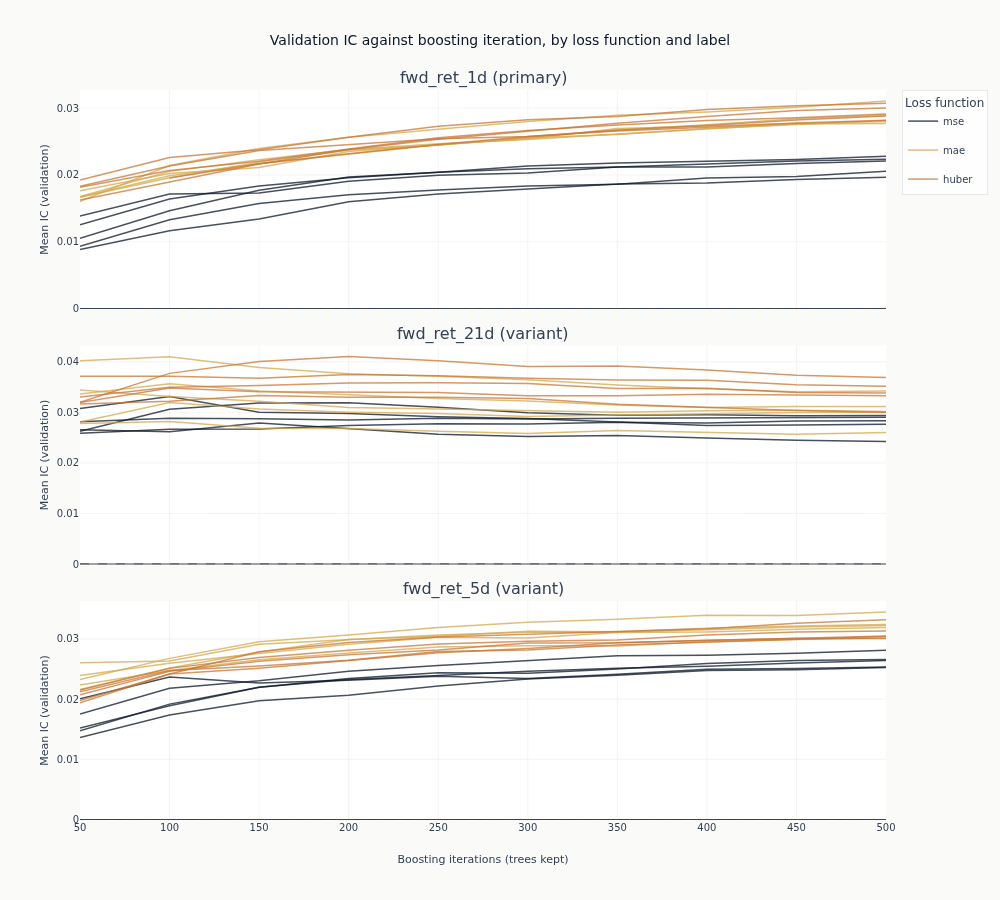

In [10]:
curves = catalog.filter("full_coverage").sort("label", "config_name", "checkpoint_value")
objectives = {"mse": COLORS["blue"], "mae": COLORS["amber"], "huber": COLORS["copper"]}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name."""
    match = next((key for key in objectives if name.endswith(key)), None)
    if match is None:
        raise ValueError(f"{name!r} does not end in a declared objective: {sorted(objectives)}")
    return match


fig_curves = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
drawn_objectives: set[str] = set()
for row, label in enumerate(panel_labels, start=1):
    panel = curves.filter(pl.col("label") == label)
    for objective, color in objectives.items():
        members = [
            name
            for name in panel.get_column("config_name").unique(maintain_order=True)
            if objective_of(name) == objective
        ]
        for config_name in members:
            series = panel.filter(pl.col("config_name") == config_name)
            fig_curves.add_trace(
                go.Scatter(
                    x=series.get_column("checkpoint_value").to_list(),
                    y=series.get_column("ic_mean").to_list(),
                    mode="lines",
                    name=objective,
                    legendgroup=objective,
                    # One legend entry per loss function, not per configuration: the colour is the
                    # claim, and forty-five named lines would bury it.
                    showlegend=objective not in drawn_objectives,
                    line=dict(color=color, width=1.5),
                    opacity=0.75,
                ),
                row=row,
                col=1,
            )
            drawn_objectives.add(objective)
    fig_curves.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_curves.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)", row=len(panel_labels), col=1)
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by loss function and label",
    height=300 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    legend=dict(title_text="Loss function"),
)
# How many lines dip below zero is a fact about the frame, so the alt text reads it rather than
# asserting it: a panel described as uniformly positive when it is not is a claim the data refutes.
dip_text = " and ".join(
    f"{row['below']} of {row['total']} in the {row['label']} panel"
    for row in curves.group_by("label")
    .agg(
        total=pl.col("config_name").n_unique(),
        below=pl.col("config_name").filter(pl.col("ic_mean") < 0).n_unique(),
    )
    .sort("label")
    .iter_rows(named=True)
)
show_plotly_with_alt(
    fig_curves,
    "Line charts of mean validation information coefficient against boosting iteration, one line "
    "per configuration, coloured by loss function: dark navy for squared error, gold for absolute "
    "error, copper for Huber. One panel per declared label, sharing the iteration axis, each "
    "carrying a dashed zero line. Counted from the underlying frame, the lines that dip below "
    f"zero at some checkpoint are {dip_text}.",
)

Whether the lines trend, and which way, is not something to read off a page of overlapping
curves. The frame below measures it: for each configuration, its IC at the last checkpoint minus
its IC at the first, and whether its best checkpoint is an interior one rather than either end.
A family still learning would show positive changes and interior peaks; a family overfitting
would show negative changes; a family with nothing to learn would show changes centred on zero
with peaks scattered anywhere.

In [11]:
drift = (
    curves.group_by("label", "config_name")
    .agg(
        first_ic=pl.col("ic_mean").sort_by("checkpoint_value").first(),
        last_ic=pl.col("ic_mean").sort_by("checkpoint_value").last(),
        peak_checkpoint=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
        first_checkpoint=pl.col("checkpoint_value").min(),
        last_checkpoint=pl.col("checkpoint_value").max(),
    )
    .with_columns(
        change=pl.col("last_ic") - pl.col("first_ic"),
        interior_peak=pl.col("peak_checkpoint").is_between(
            pl.col("first_checkpoint"), pl.col("last_checkpoint"), closed="none"
        ),
    )
)
trees_effect = (
    drift.group_by("label")
    .agg(
        configurations=pl.len(),
        median_change=pl.col("change").median(),
        ended_lower=(pl.col("change") < 0).sum(),
        interior_peaks=pl.col("interior_peak").sum(),
    )
    .sort("label")
)
trees_effect

label,configurations,median_change,ended_lower,interior_peaks
str,u32,f64,u32,u32
"""fwd_ret_1d""",15,0.011027,0,0
"""fwd_ret_21d""",15,-0.001669,8,12
"""fwd_ret_5d""",15,0.01062,0,0


### Comparing every configuration at the same training length

The curves are coloured by objective because that is the axis with a mechanism behind it. If
heavy tails are steering the squared-error fits, the three colours should separate, and they
should separate more as trees are added, since each additional tree is fitted to the residuals
the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's own final state -
the comparison that does not require choosing anything after the fact. Every preset here
declares the same `max_iterations`, so that is also a comparison at equal training length, and
the line printed under the frame says so rather than assuming it. The configurations are held in one order across
the panels - their ranking on the primary label - so a panel that does not descend is a horizon
that orders the grid differently.

The final state below is each configuration's own last checkpoint, so a configuration declaring
a shorter schedule than its neighbours is still compared at the state it reached. Every preset
in this grid declares the same `max_iterations`, so today those last checkpoints coincide, and
the line printed under the agreement frame reports the iteration count they all landed on.

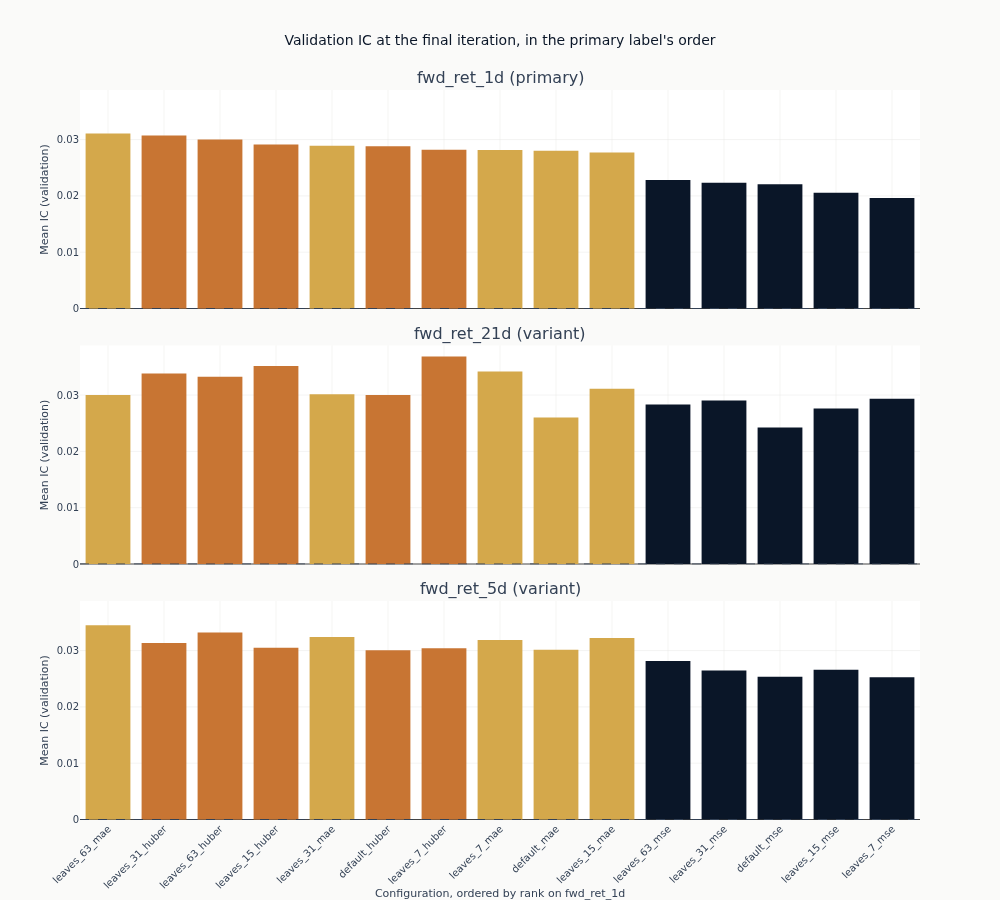

In [12]:
final = (
    catalog.filter(
        pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("label", "config_name")
    )
    .filter("full_coverage")
    .sort(["label", "ic_mean"], descending=[False, True])
)
final_iterations = sorted(set(final.get_column("checkpoint_value").to_list()))
config_order = (
    final.filter(pl.col("label") == order_label)
    .sort("ic_mean", descending=True)
    .get_column("config_name")
    .to_list()
)

# `shared_yaxes` matches axes across columns, so with one column it does nothing and each
# panel would be rescaled to fill itself. Matching every row to the first is what puts the
# horizons on one vertical scale, which is what stacking them is for.
fig_final = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = final.filter(pl.col("label") == label)
    order = [name for name in config_order if name in set(panel.get_column("config_name"))]
    order += [name for name in panel.get_column("config_name").to_list() if name not in order]
    panel = panel.with_columns(
        rank=pl.col("config_name").replace_strict(
            {name: index for index, name in enumerate(order)}, return_dtype=pl.Int32
        )
    ).sort("rank")
    fig_final.add_trace(
        go.Bar(
            x=panel.get_column("config_name").to_list(),
            y=panel.get_column("ic_mean").to_list(),
            marker_color=[
                objectives[objective_of(name)] for name in panel.get_column("config_name")
            ],
            showlegend=False,
        ),
        row=row,
        col=1,
    )
    fig_final.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_final.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
    if row > 1:
        fig_final.update_yaxes(matches="y", row=row, col=1)
fig_final.update_xaxes(
    title_text=f"Configuration, ordered by rank on {order_label}",
    tickangle=-45,
    row=len(panel_labels),
    col=1,
)
fig_final.update_layout(
    title="Validation IC at the final iteration, in the primary label's order",
    height=300 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
)
show_plotly_with_alt(
    fig_final,
    "Bar charts of mean validation information coefficient at the final boosting iteration, one "
    "panel per declared label sharing a vertical scale, bars coloured by loss function - dark "
    "navy for squared error, gold for absolute error, copper for Huber - and held in the primary "
    "label's ranking order across every panel. The primary panel descends by construction; "
    "whether the others do is the comparison the figure exists for. Each panel carries a dashed "
    "zero line.",
)

The frame below puts a number on what the chart shows: for each label, the rank correlation
between that label's ordering of the grid and the primary label's, and how far the grid spreads
at that horizon. A value near one means the horizon reorders nothing; a value near zero means
the configuration that wins at one horizon carries no information about which wins at another.

In [13]:
order_ic = final.filter(pl.col("label") == order_label).select("config_name", "ic_mean")
agreement = (
    final.join(order_ic, on="config_name", suffix="_primary")
    .group_by("label")
    .agg(
        configurations=pl.len(),
        rank_agreement=pl.corr(
            pl.col("ic_mean").rank(), pl.col("ic_mean_primary").rank(), method="pearson"
        ),
        best_ic=pl.col("ic_mean").max(),
        spread=pl.col("ic_mean").max() - pl.col("ic_mean").min(),
    )
    .sort("label")
)
if len(final_iterations) == 1:
    print(f"compared at {final_iterations[0]} boosting iterations")
else:
    # Say so rather than printing one of them: the panel is then a comparison of final states at
    # different training lengths, which is a weaker claim than the text above makes.
    print(f"compared at each configuration's own final iteration, which differ: {final_iterations}")
agreement

compared at 500 boosting iterations


label,configurations,rank_agreement,best_ic,spread
str,u32,f64,f64,f64
"""fwd_ret_1d""",15,1.0,0.031069,0.01144
"""fwd_ret_21d""",15,0.628571,0.036858,0.012613
"""fwd_ret_5d""",15,0.825,0.034489,0.009213


## 5. What to notice

**The learning curves say whether the checkpoint dimension is buying anything.** If every
configuration's highest-IC checkpoint is its last, the ten checkpoints cost storage and bought
nothing, and the grid could have been scored at the end. If those checkpoints are interior
and the curves turn over, then stopping early is a real dial and the `trees_effect` frame says
on which labels. Read that frame before reading the ranking: it is the difference between a grid
where capacity binds and one where it does not.

**The loss functions are a statement about the tails, and rank IC is the wrong metric to reward
them by.** Squared error spends its capacity getting the largest moves approximately right;
rank IC does not care how large a move was, only whether it was ranked above the next one. A
grid where the absolute-error and Huber configurations lead is not evidence that squared error
fitted badly - it is evidence that the two disagree about what the model was for. Which one is
right is settled by the backtest, not here.

**The horizon comparison is the finding that generalizes.** The three labels are the same
features and the same folds, differing only in how far ahead the label looks. Where the
orderings agree, the grid is measuring something about the models; where they disagree, it is
measuring something about the horizon, and a configuration chosen on one horizon should not be
carried to another on the strength of that choice.

**Read the ranking with the coverage column or it will mislead you.** A configuration whose
predictions collapse to near-constant on some dates contributes no rank correlation there, so
its `ic_mean` is an average over a sample it selected itself. `full_coverage` marks the ones
measured on all of them, and the figures draw only those.

**None of this selects anything.** IC measures whether predictions rank names correctly, not
whether a strategy trading them makes money after costs and turnover, and on a three-thousand
name panel turnover is the binding constraint rather than an afterthought. Selection is on
validation backtest Sharpe over the population this notebook just published, and it happens in
[`16_backtest`](16_backtest.ipynb).

**Known limitations.** The IC here is an average of per-date rank correlations with no
adjustment for the serial dependence that overlapping forward returns create, so it is a ranking
diagnostic rather than a test. The grid varies capacity and loss at fixed features and fixed
training length, but not at a fixed learning rate - the `default` profile runs at twice the
ladder's - so the `default` rows are not comparable with the rest on
capacity alone, and nothing here separates a learning-rate effect from a regularization one.
Every number is measured on
the validation folds, which have been read many times over by the time a case study reaches this
notebook.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) asks whether a network that learns its own
feature interactions finds more in this panel than a tree ensemble does.